# **Galileo B**

**TEAM 1 - Victor Ostolaza, Muhammad Sawaiz Fatar, Vedaant Rath, Arpita Ram Samant, Sam Sheng**

## Introduction

This notebook is meant to get your started for the Galileo B case.
Please ensure that `model_uncertainty.py` and `simresults_charts.py` are uploaded to your Colab environment before running this notebook.

In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('.')

from simresults_charts import * # Importing custom functions for visualizing Monte Carlo simulation results.
from model_uncertainty import *  # Importing utility functions for model calculations and data processing.

## Deterministic Calculator

In [2]:
def profit_calculator(ks_order_quantity,  # order decision
           time_to_delivery=95,
           k_supplier_price=8,
           k_premium_price=10,
           k_regular_capacity=15000,
           t_resume=35,
           t_capacity=1000,
           t_price=5,
           rmb_usd=7,
           other_part_cost=90,
           labor_cost_binocular=22.5,
           salvage_value_eyepiece=3,
           salvage_value_other_parts=63,
           time_to_assemble=35,
           **kwargs): # Allows function to ignore extra arguments passed from simulation wrappers

    # Static Revenue and Binocular Production Parameters
    eyepieces_per_binocular = 2
    revenue_per_unit = 22
    total_demand = 16000

    # Calculate Taizhou order quantity
    first_step = np.maximum(0, time_to_delivery - t_resume - time_to_assemble)
    second_step = first_step * t_capacity
    tz_order_quantity = np.minimum(total_demand * 2, second_step)

    # Total eyepieces available
    total_eyepieces = tz_order_quantity + ks_order_quantity

    # Binoculars sold (limited by demand and available eyepieces)
    binoculars_sold = np.minimum(total_eyepieces / eyepieces_per_binocular, total_demand)

    # Calculate total costs
    paid_tz = tz_order_quantity * t_price
    paid_ks_regular = k_supplier_price * np.minimum(k_regular_capacity, ks_order_quantity)
    paid_ks_premium = np.maximum(0, ks_order_quantity - k_regular_capacity) * k_premium_price
    cost_other = other_part_cost * total_demand
    labor_cost = labor_cost_binocular * binoculars_sold
    total_cost = paid_tz + paid_ks_regular + paid_ks_premium + cost_other + labor_cost

    # Calculate total revenue
    revenue_from_binoculars = binoculars_sold * revenue_per_unit * rmb_usd
    total_salvage_eyepieces = (total_eyepieces - 2 * binoculars_sold) * salvage_value_eyepiece
    total_salvage_other = (total_demand - binoculars_sold) * salvage_value_other_parts
    total_revenue = revenue_from_binoculars + total_salvage_eyepieces + total_salvage_other

    # Profit
    calculated_profit = total_revenue - total_cost

    return calculated_profit

In [3]:
# test the profit function
result = profit_calculator(ks_order_quantity=0)
print(f"Profit: {result}")

Profit: 299250.0


## Modeling Key Uncertainties

In [4]:
### Some information discussed in Galileo (B) that are useful for modeling the uncertainties ###
# disruption_scenario_probabilities = [0.2, 0.6, 0.2]
# 10-50-90s for Taizhou resume time, t_resume (in days)
#                   {1: [21,28,35],
#                    2: [21,35,49],
#                    3: [28,42,56]}
# 10-50-90s for Taizhou capacity under scenario 3 (pessimistic scenario): [400, 500, 800]
# 10-50-90s for the labor cost: [18, 22.5, 25.5]
# eyepiece_salvage_scenario_probabilities = [0.2, 0.8] (0.2 for future orders, 0.8 for no future orders)
# range of salvage_value_eyepiece without future orders: [2,4]
# 10-50-90s for the exchange rate: [6.7, 7, 7.3]

from scipy.stats import norm # Importing normal distribution functions for calculations to compute the standard deviation of exchange rate.

# Implement the following (random) functions to simulate the uncertain parameters. Each of these functions should return a single random value each time they are called.
# When you implement the functions, you MAY NEED add input variables in some of the (random) functions.

# Also, when you need to fit a distribution with 10-50-90 assessments, please set x_min = 0.5*p10 and x_max = 1.5*p90

def exchange_rate_sim(rmb_usd_mean, rmb_usd_p10):
  """Generates a random value for the exchange rate, rmb_usd, using a normal distribution"""
  sd = (rmb_usd_mean - rmb_usd_p10) / 1.28
  rate = norm.rvs(loc=rmb_usd_mean, scale=sd)  # returns a scalar (removed size=1)
  return rate

def scenario_sim():
  """Generates a random disruption scenario."""
  scenarios = [1, 2, 3]
  probabilities = [0.2, 0.6, 0.2]
  scenario = np.random.choice(scenarios, p=probabilities)
  return scenario

def t_resume_sim(scenario):
  """Generates a random value for the time to resume production in Taizhou, t_resume."""
  resume_dict = {1: [21, 28, 35],
                 2: [21, 35, 49],
                 3: [28, 42, 56]}
  resume_dist = resume_dict[scenario]
  resume_time = fit_10_50_90(0.5 * resume_dist[0], resume_dist[0], resume_dist[1], resume_dist[2], 1.5 * resume_dist[2])
  return resume_time

def t_capacity_sim(scenario):
  """Generates a random value for the production capacity in Taizhou, t_capacity."""
  if scenario == 1 or scenario == 2:
    return 1000
  else:
    return fit_10_50_90(0.5 * 400, 400, 500, 800, 1.5 * 800)

def labor_cost_binocular_sim():
  """Generates a random value for the labor cost per binocular, labor_cost_binocular."""
  return fit_10_50_90(0.5 * 18, 18, 22.5, 25.5, 1.5 * 25.5)

def salvage_value_eyepiece_sim():
  """Generates a random value for the salvage value per eyepiece, salvage_value_eyepiece."""
  future_order = np.random.binomial(1, 0.2)
  if future_order == 1:
    return 5
  else:
    return np.random.uniform(2, 4)

## Set up the Trial Function

In [ ]:
def sim_one_trial(ks_order_quantity,rmb_usd_mean = 7, rmb_usd_p10 = 6.7, **kwargs):
    """
    Runs one simulation trial.

    Args:
        ks_order_quantity: The decision variable.
        rmb_usd_mean: Mean for exchange rate simulation.
        rmb_usd_p10: 10th percentile for exchange rate simulation.
        **kwargs: Any other arguments to pass to the profit function (e.g., time_to_delivery, costs).
    """
    sim_rmb_usd = exchange_rate_sim(rmb_usd_mean,rmb_usd_p10)
    sim_scenario = scenario_sim()
    sim_t_resume = t_resume_sim(sim_scenario)
    sim_t_capacity = t_capacity_sim(sim_scenario)
    sim_labor_cost_binocular = labor_cost_binocular_sim()
    sim_salvage_value_eyepiece = salvage_value_eyepiece_sim()

    # Calculate profit using the simulated uncertainties
    profit = profit_calculator(ks_order_quantity, rmb_usd=sim_rmb_usd,
                  t_resume=sim_t_resume, t_capacity=sim_t_capacity,
                  labor_cost_binocular=sim_labor_cost_binocular,
                  salvage_value_eyepiece=sim_salvage_value_eyepiece, **kwargs)
    return profit

## Define Simulation Function

In [6]:
def simulate(ks_order_quantity, rmb_usd_mean=7, rmb_usd_p10=6.7, trials=10000, seed=None, **kwargs):
  if seed is not None:
    np.random.seed(seed)
  profits = []
  for i in range(trials):
    profits.append(sim_one_trial(ks_order_quantity, rmb_usd_mean=rmb_usd_mean, rmb_usd_p10=rmb_usd_p10, **kwargs))
  res_df = pd.DataFrame({'Profit': profits})
  return res_df

## Run Simulation Function for Different Values of Order Quantity

In [7]:
def multiple_order_quantities(seed, order_quantities=None, trials=10000):
  """Run simulation for multiple order quantities and return combined DataFrame."""
  if order_quantities is None:
    order_quantities = list(range(0, 33000, 1000))  # 0 to 32,000 in steps of 1,000
  simulated_df = pd.DataFrame()
  for qty in order_quantities:
    res = simulate(ks_order_quantity=qty, seed=seed, trials=trials)
    temp = pd.DataFrame({f"Profit@{qty}": res['Profit']})
    if simulated_df.empty:
      simulated_df = temp
    else:
      simulated_df = pd.concat([simulated_df, temp], axis=1)
  simulated_df.to_csv('result_df.csv', index=False)
  return simulated_df

In [8]:
simulated_df = multiple_order_quantities(seed=1, trials=10000)
print(f"Simulated {len(simulated_df.columns)} order quantities, {len(simulated_df)} trials each")

Simulated 33 order quantities, 10000 trials each


## Profit Statistics

In [9]:
# Show statistics for a representative subset of order quantities
display_cols = [f"Profit@{q}" for q in [0, 8000, 16000, 20000, 24000, 28000, 32000]]
profit_stats = basic_statistics("result_df.csv", display_cols)

In [10]:
profit_stats

,Profit@0,Profit@8000,Profit@16000,Profit@20000,Profit@24000,Profit@28000,Profit@32000
mean,1.988935e+05,3.098551e+05,3.711193e+05,3.809935e+05,3.765881e+05,3.617318e+05,3.448565e+05
standard deviation,3.179413e+05,2.418723e+05,1.696098e+05,1.402141e+05,1.235633e+05,1.173938e+05,1.165952e+05
variance,1.010867e+11,5.850222e+10,2.876749e+10,1.965999e+10,1.526790e+10,1.378130e+10,1.359444e+10
median,2.590477e+05,3.724812e+05,4.010365e+05,3.924706e+05,3.822536e+05,3.615076e+05,3.451633e+05
mean standard error,3.179413e+03,2.418723e+03,1.696098e+03,1.402141e+03,1.235633e+03,1.173938e+03,1.165952e+03


In [11]:
det_profit_stats = detailed_statistics("result_df.csv", display_cols)
det_profit_stats

,Profit@0,Profit@8000,Profit@16000,Profit@20000,Profit@24000,Profit@28000,Profit@32000
mean,1.988935e+05,3.098551e+05,3.711193e+05,3.809935e+05,3.765881e+05,3.617318e+05,3.448565e+05
standard deviation,3.179413e+05,2.418723e+05,1.696098e+05,1.402141e+05,1.235633e+05,1.173938e+05,1.165952e+05
variance,1.010867e+11,5.850222e+10,2.876749e+10,1.965999e+10,1.526790e+10,1.378130e+10,1.359444e+10
median,2.590477e+05,3.724812e+05,4.010365e+05,3.924706e+05,3.822536e+05,3.615076e+05,3.451633e+05
mean standard error,3.179413e+03,2.418723e+03,1.696098e+03,1.402141e+03,1.235633e+03,1.173938e+03,1.165952e+03
min,-4.320000e+05,-3.320550e+05,-1.983133e+05,-2.054971e+05,-7.309718e+04,-1.647027e+05,-1.057977e+05
10th_percentile,-2.884385e+05,-8.154428e+04,1.090882e+05,1.841905e+05,2.146042e+05,2.155325e+05,1.990163e+05
20th_percentile,-1.028358e+05,9.554118e+04,2.485780e+05,2.743650e+05,2.779345e+05,2.693161e+05,2.528276e+05
30th_percentile,8.965205e+03,2.112159e+05,3.198236e+05,3.264461e+05,3.184136e+05,3.050132e+05,2.890384e+05
40th_percentile,1.361882e+05,3.055660e+05,3.652004e+05,3.617361e+05,3.524260e+05,3.340654e+05,3.185798e+05


In [12]:
conf_int = compute_confidence_interval("result_df.csv", display_cols)
conf_int

,Profit@0,Profit@8000,Profit@16000,Profit@20000,Profit@24000,Profit@28000,Profit@32000
lower_bound,192661.210791,305113.878844,367794.563203,378245.058314,374166.021415,359430.641781,342570.979837
upper_bound,205125.791043,314596.247655,374443.950409,383742.014428,379010.201564,364032.950081,347141.981729


## Cumulative Probability Function

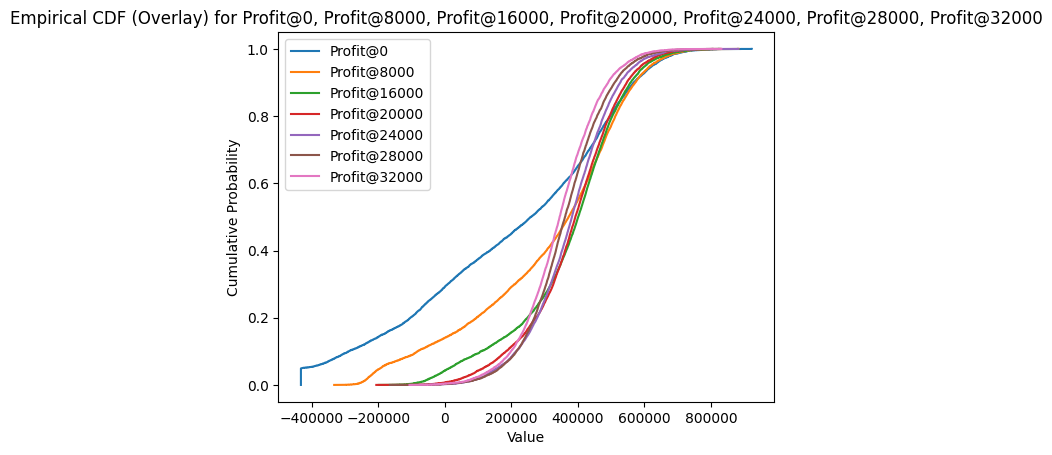

In [13]:
create_simresults_charts("result_df.csv", display_cols, overlay=True)

## Expected Profit vs. Order Quantity

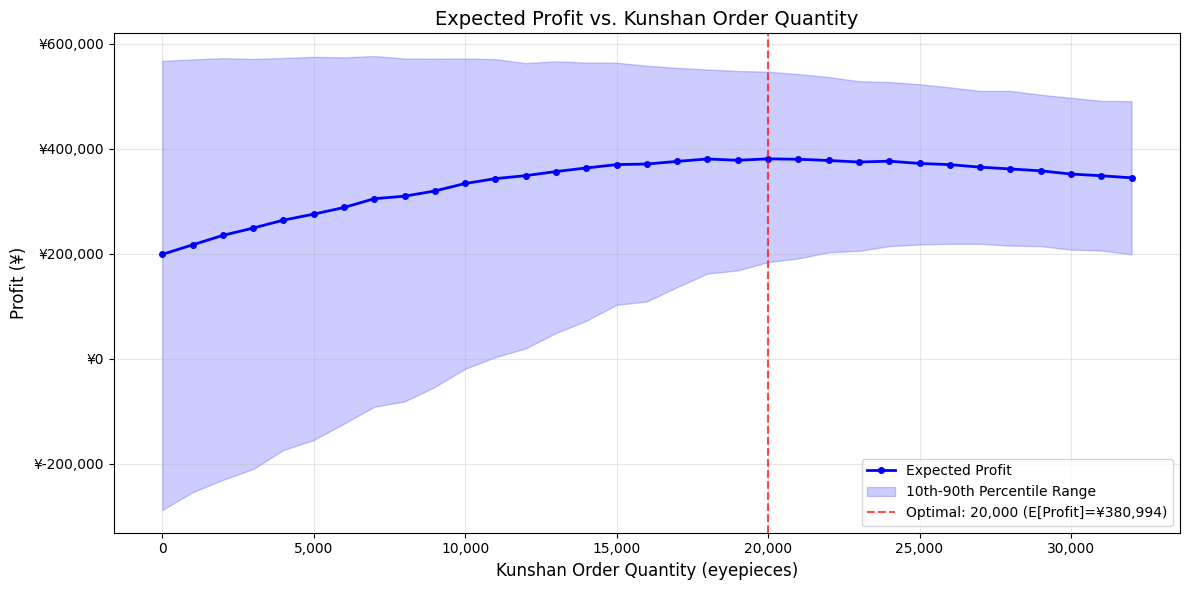


Optimal Kunshan order quantity: 20,000 eyepieces
Expected profit at optimal: ¥380,994


In [14]:
import matplotlib.pyplot as plt

order_quantities = list(range(0, 33000, 1000))
means = [simulated_df[f"Profit@{q}"].mean() for q in order_quantities]
stds = [simulated_df[f"Profit@{q}"].std() for q in order_quantities]
p10s = [simulated_df[f"Profit@{q}"].quantile(0.10) for q in order_quantities]
p90s = [simulated_df[f"Profit@{q}"].quantile(0.90) for q in order_quantities]

# Find the optimal order quantity
best_idx = np.argmax(means)
best_qty = order_quantities[best_idx]
best_mean = means[best_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(order_quantities, means, 'b-o', markersize=4, label='Expected Profit', linewidth=2)
ax.fill_between(order_quantities, p10s, p90s, alpha=0.2, color='blue', label='10th-90th Percentile Range')
ax.axvline(x=best_qty, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {best_qty:,} (E[Profit]=¥{best_mean:,.0f})')
ax.set_xlabel('Kunshan Order Quantity (eyepieces)', fontsize=12)
ax.set_ylabel('Profit (¥)', fontsize=12)
ax.set_title('Expected Profit vs. Kunshan Order Quantity', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'¥{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"\nOptimal Kunshan order quantity: {best_qty:,} eyepieces")
print(f"Expected profit at optimal: ¥{best_mean:,.0f}")

## Risk-Return Tradeoff

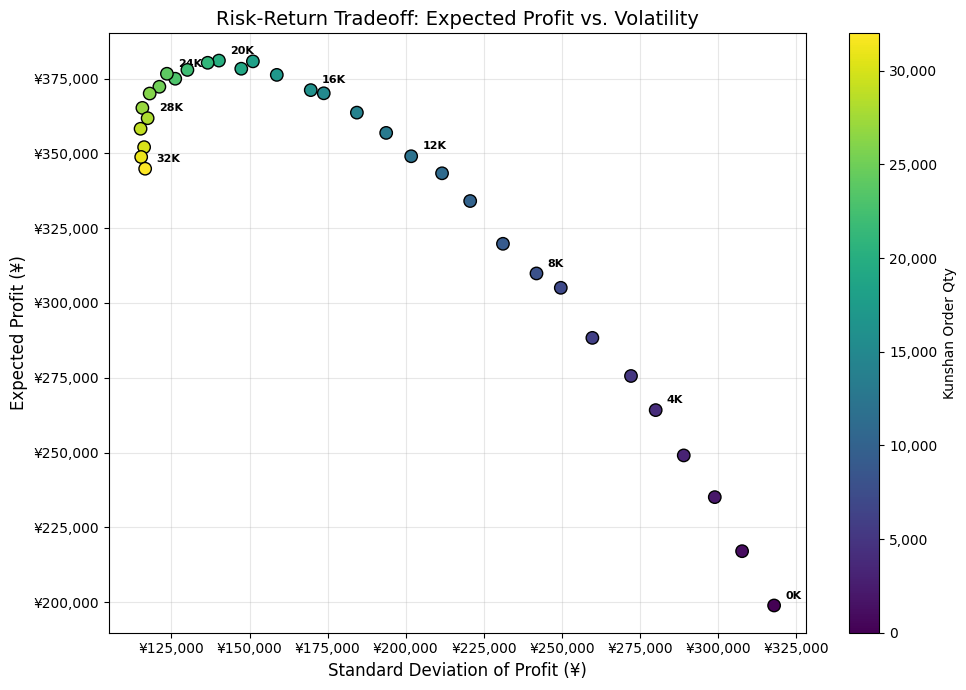

In [15]:
# Risk-Return: Expected Profit vs. Standard Deviation
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(stds, means, c=order_quantities, cmap='viridis', s=80, edgecolors='black', zorder=5)
cbar = plt.colorbar(scatter, ax=ax, label='Kunshan Order Qty')
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Label key points
for i, qty in enumerate(order_quantities):
    if qty % 4000 == 0:
        ax.annotate(f'{qty//1000}K', (stds[i], means[i]), textcoords="offset points",
                    xytext=(8, 5), fontsize=8, fontweight='bold')

ax.set_xlabel('Standard Deviation of Profit (¥)', fontsize=12)
ax.set_ylabel('Expected Profit (¥)', fontsize=12)
ax.set_title('Risk-Return Tradeoff: Expected Profit vs. Volatility', fontsize=14)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'¥{int(x):,}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'¥{int(x):,}'))
plt.tight_layout()
plt.show()

## Downside Risk Analysis

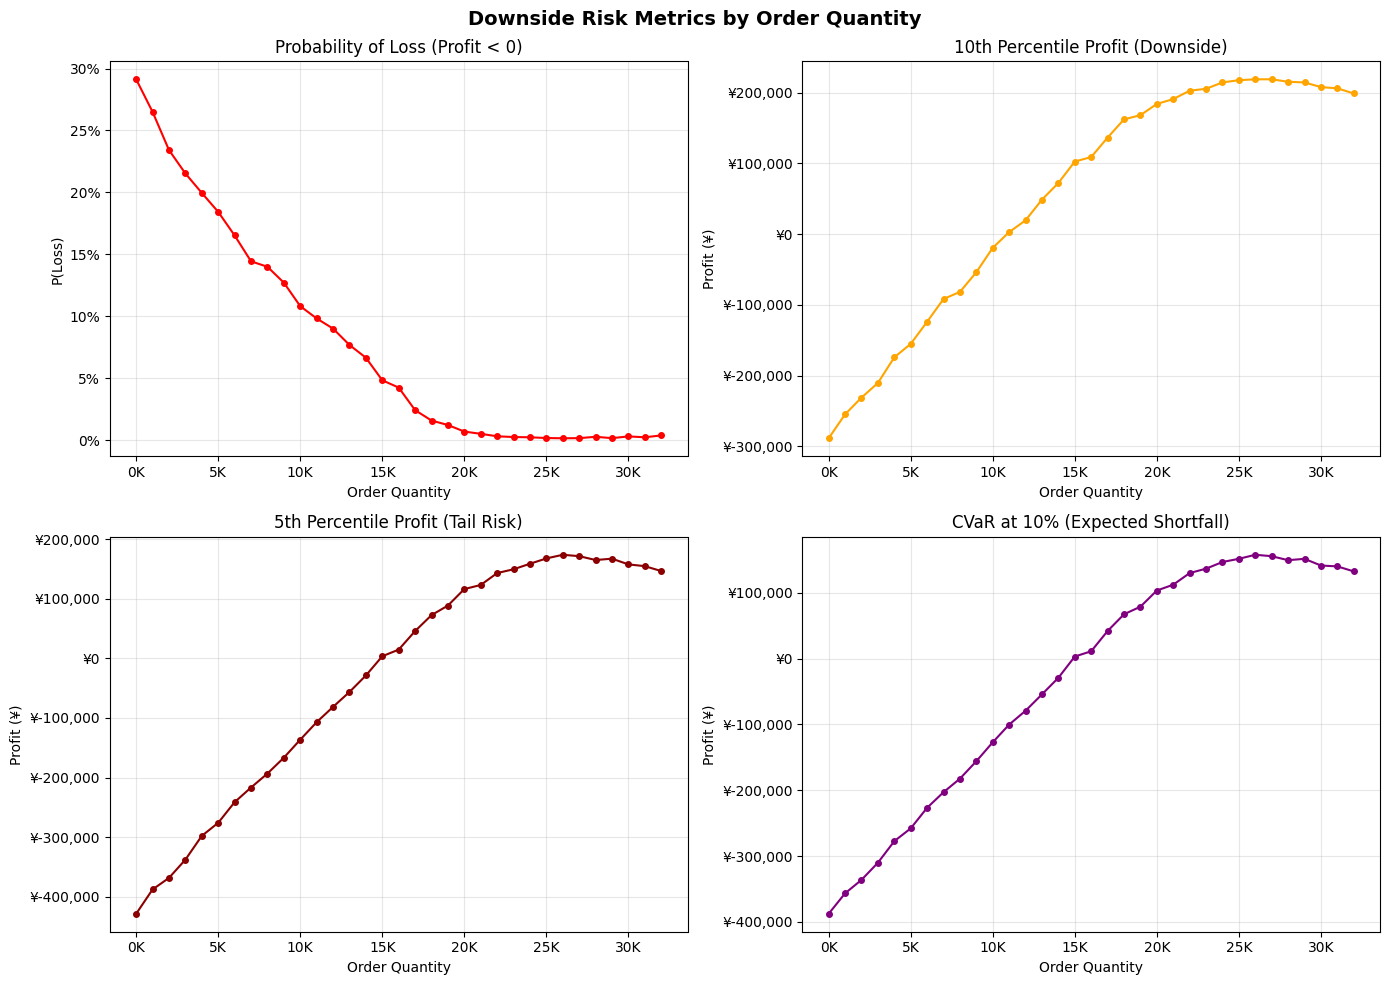

,E[Profit],Std Dev,P(Loss),10th Pctl,CVaR 10%
Order Qty,,,,,
0,"¥198,894","¥317,941",29.1%,"¥-288,438","¥-387,594"
1000,"¥217,038","¥307,693",26.5%,"¥-254,603","¥-356,570"
2000,"¥235,100","¥298,952",23.4%,"¥-230,972","¥-336,146"
3000,"¥249,042","¥289,015",21.5%,"¥-210,308","¥-310,149"
4000,"¥264,184","¥280,033",20.0%,"¥-174,005","¥-277,349"
5000,"¥275,586","¥272,129",18.4%,"¥-155,029","¥-257,923"
6000,"¥288,326","¥259,763",16.5%,"¥-123,777","¥-226,649"
7000,"¥305,059","¥249,655",14.4%,"¥-91,519","¥-202,992"
8000,"¥309,855","¥241,872",14.0%,"¥-81,544","¥-182,437"


In [16]:
# Downside risk metrics for each order quantity
prob_loss = [(simulated_df[f"Profit@{q}"] < 0).mean() for q in order_quantities]
p10_profit = [simulated_df[f"Profit@{q}"].quantile(0.10) for q in order_quantities]
p5_profit = [simulated_df[f"Profit@{q}"].quantile(0.05) for q in order_quantities]

# CVaR (Expected Shortfall) at 10% level
cvar_10 = []
for q in order_quantities:
    col = simulated_df[f"Profit@{q}"]
    threshold = col.quantile(0.10)
    cvar_10.append(col[col <= threshold].mean())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# P(Loss)
axes[0, 0].plot(order_quantities, prob_loss, 'r-o', markersize=4)
axes[0, 0].set_title('Probability of Loss (Profit < 0)', fontsize=12)
axes[0, 0].set_xlabel('Order Quantity')
axes[0, 0].set_ylabel('P(Loss)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))

# 10th Percentile Profit
axes[0, 1].plot(order_quantities, p10_profit, 'orange', marker='o', markersize=4)
axes[0, 1].set_title('10th Percentile Profit (Downside)', fontsize=12)
axes[0, 1].set_xlabel('Order Quantity')
axes[0, 1].set_ylabel('Profit (¥)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'¥{int(x):,}'))

# 5th Percentile Profit
axes[1, 0].plot(order_quantities, p5_profit, 'darkred', marker='o', markersize=4)
axes[1, 0].set_title('5th Percentile Profit (Tail Risk)', fontsize=12)
axes[1, 0].set_xlabel('Order Quantity')
axes[1, 0].set_ylabel('Profit (¥)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'¥{int(x):,}'))

# CVaR at 10%
axes[1, 1].plot(order_quantities, cvar_10, 'purple', marker='o', markersize=4)
axes[1, 1].set_title('CVaR at 10% (Expected Shortfall)', fontsize=12)
axes[1, 1].set_xlabel('Order Quantity')
axes[1, 1].set_ylabel('Profit (¥)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'¥{int(x):,}'))

plt.suptitle('Downside Risk Metrics by Order Quantity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
risk_df = pd.DataFrame({
    'Order Qty': order_quantities,
    'E[Profit]': [f'¥{m:,.0f}' for m in means],
    'Std Dev': [f'¥{s:,.0f}' for s in stds],
    'P(Loss)': [f'{p:.1%}' for p in prob_loss],
    '10th Pctl': [f'¥{p:,.0f}' for p in p10_profit],
    'CVaR 10%': [f'¥{c:,.0f}' for c in cvar_10]
}).set_index('Order Qty')
risk_df

In [17]:
def compute_ce(sim_values, RT=10_000):
  """Return the Certainty Equivalent (CARA): CE solves u(CE)=E[u(x)].

  - u(x)=1-exp(-x/RT).  Arguments: sim_values (array-like), RT (float).
  - Minimal implementation for teaching; no input validation.
  """
  sim_arr = np.asarray(sim_values, dtype=float)
  utilities = 1.0 - np.exp(-sim_arr / RT)
  return -np.log(1.0 - np.mean(utilities)) * RT




In [18]:
rt_vals = [20000, 40000, 100000, 200000, 370000]
ce_display_cols = display_cols  # use representative subset for table display

ce_values_df = pd.DataFrame(index=ce_display_cols, columns=rt_vals)

for rt in rt_vals:
    for s in ce_display_cols:
        ce_values_df.loc[s, rt] = compute_ce(simulated_df[s], RT=rt)

ce_values_df

,20000,40000,100000,200000,370000
Profit@0,-373207.426449,-318653.27711,-185856.349345,-48655.985052,56073.694021
Profit@8000,-187297.814129,-120837.142753,16367.383635,142359.705011,221186.323492
Profit@16000,-36445.203574,54144.297675,196472.651834,285931.707217,327993.044737
Profit@20000,-22442.032466,117912.007801,265985.511057,326738.645329,352913.116548
Profit@24000,78534.742633,178320.327536,294167.394165,336820.830725,355505.861486
Profit@28000,16796.281073,156100.190711,287602.685401,326334.183244,342885.077231
Profit@32000,56539.317359,160750.876696,272326.146896,309923.292701,326247.812492


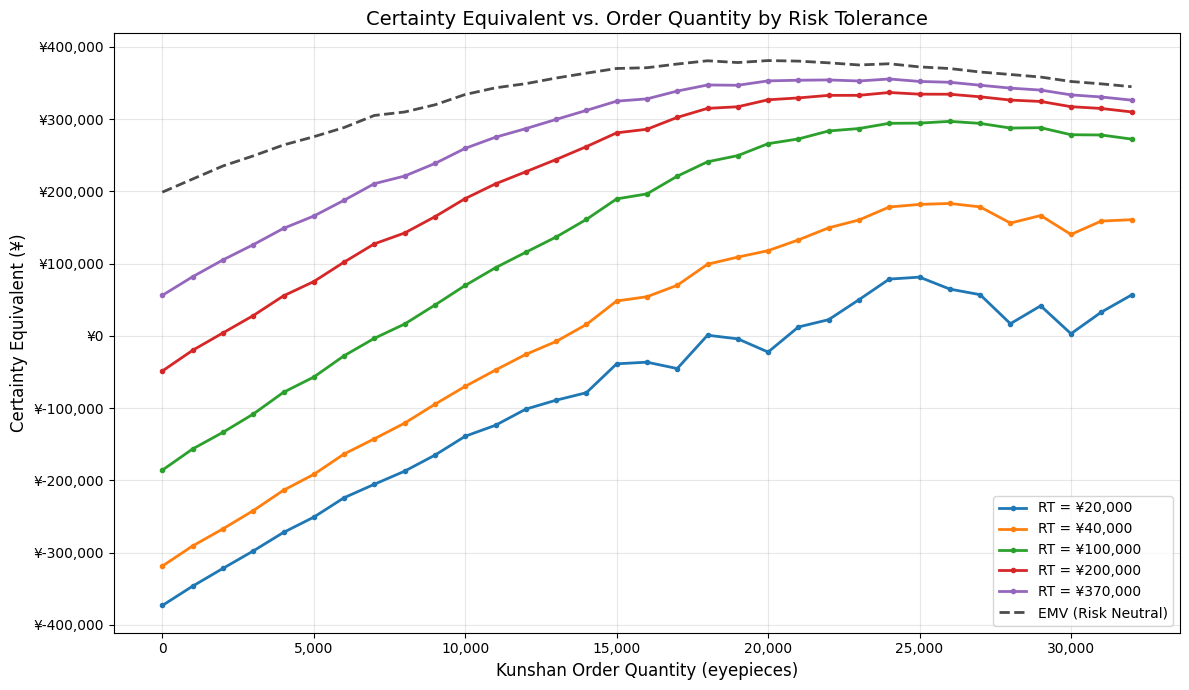

Optimal order quantity by risk tolerance:
  RT = ¥ 20,000: Order 25,000 eyepieces (CE = ¥    81,267)
  RT = ¥ 40,000: Order 26,000 eyepieces (CE = ¥   183,245)
  RT = ¥100,000: Order 26,000 eyepieces (CE = ¥   296,866)
  RT = ¥200,000: Order 24,000 eyepieces (CE = ¥   336,821)
  RT = ¥370,000: Order 24,000 eyepieces (CE = ¥   355,506)
  Risk Neutral:  Order 20,000 eyepieces (EMV = ¥   380,994)


In [19]:
# CE vs. Order Quantity plot (using full grid of order quantities)
fig, ax = plt.subplots(figsize=(12, 7))

for rt in rt_vals:
    ce_by_qty = []
    for q in order_quantities:
        ce_by_qty.append(compute_ce(simulated_df[f"Profit@{q}"], RT=rt))
    ax.plot(order_quantities, ce_by_qty, '-o', markersize=3, label=f'RT = ¥{rt:,}', linewidth=2)

# Also plot EMV (risk-neutral)
ax.plot(order_quantities, means, 'k--', markersize=3, label='EMV (Risk Neutral)', linewidth=2, alpha=0.7)

ax.set_xlabel('Kunshan Order Quantity (eyepieces)', fontsize=12)
ax.set_ylabel('Certainty Equivalent (¥)', fontsize=12)
ax.set_title('Certainty Equivalent vs. Order Quantity by Risk Tolerance', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'¥{int(x):,}'))
plt.tight_layout()
plt.show()

# Print optimal order for each risk tolerance
print("Optimal order quantity by risk tolerance:")
for rt in rt_vals:
    ce_by_qty = [compute_ce(simulated_df[f"Profit@{q}"], RT=rt) for q in order_quantities]
    opt_idx = np.argmax(ce_by_qty)
    print(f"  RT = ¥{rt:>7,}: Order {order_quantities[opt_idx]:>6,} eyepieces (CE = ¥{ce_by_qty[opt_idx]:>10,.0f})")
print(f"  Risk Neutral:  Order {best_qty:>6,} eyepieces (EMV = ¥{best_mean:>10,.0f})")

## Distribution Validation

Quick sanity check: histograms of the simulated uncertain inputs to confirm distributions look reasonable.

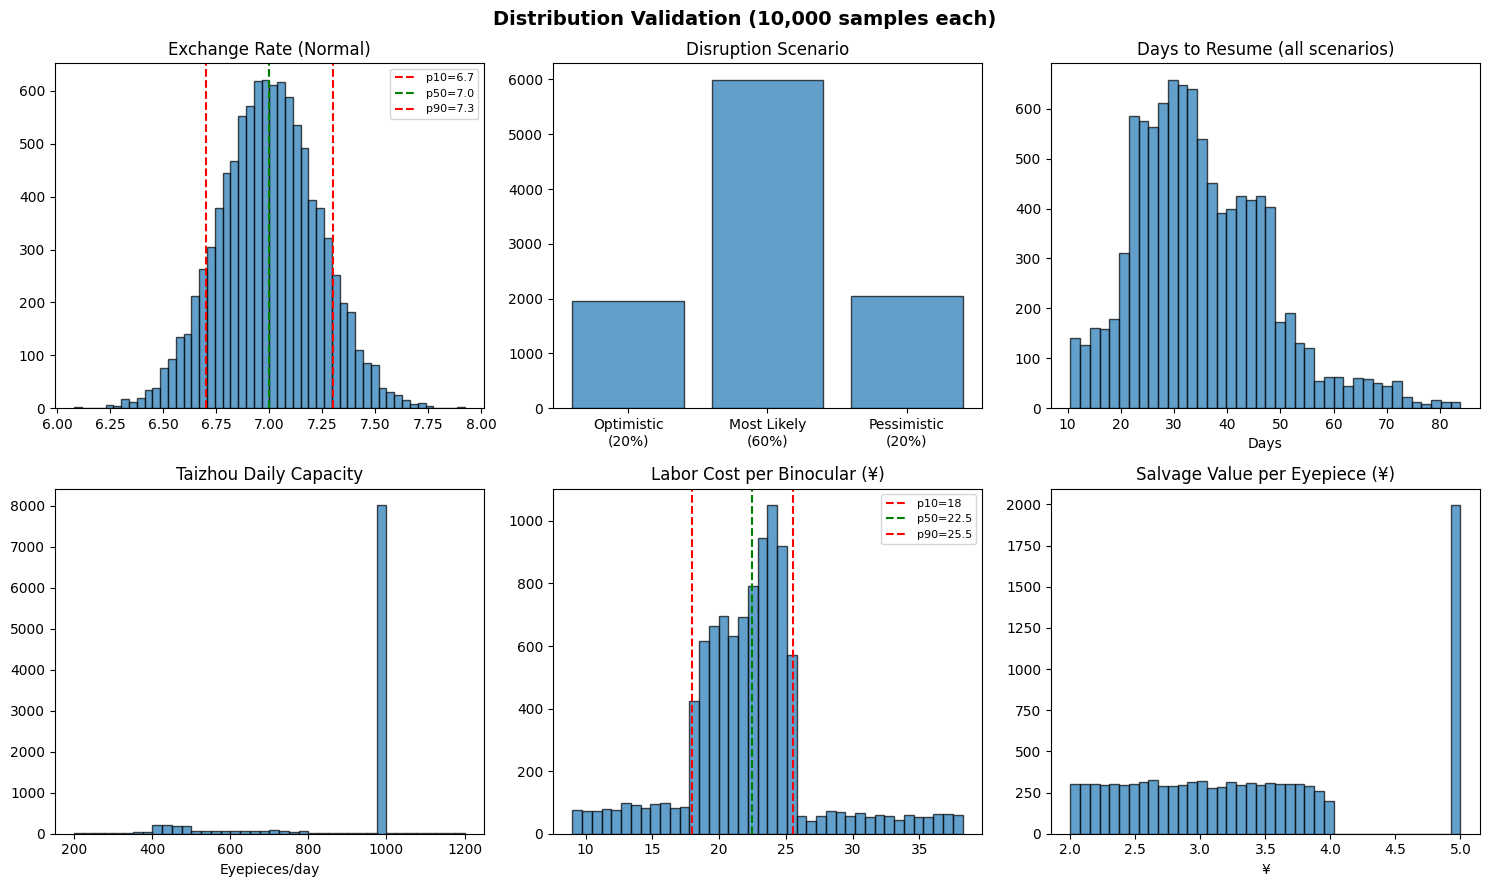

In [20]:
np.random.seed(42)
n_check = 10000

# Generate samples for each uncertainty
check_rates = [exchange_rate_sim(7, 6.7) for _ in range(n_check)]
check_scenarios = [scenario_sim() for _ in range(n_check)]
check_resume = [t_resume_sim(scenario_sim()) for _ in range(n_check)]
check_capacity = [t_capacity_sim(scenario_sim()) for _ in range(n_check)]
check_labor = [labor_cost_binocular_sim() for _ in range(n_check)]
check_salvage = [salvage_value_eyepiece_sim() for _ in range(n_check)]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].hist(check_rates, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=6.7, color='r', linestyle='--', label='p10=6.7')
axes[0, 0].axvline(x=7.0, color='g', linestyle='--', label='p50=7.0')
axes[0, 0].axvline(x=7.3, color='r', linestyle='--', label='p90=7.3')
axes[0, 0].set_title('Exchange Rate (Normal)')
axes[0, 0].legend(fontsize=8)

axes[0, 1].hist(check_scenarios, bins=[0.5, 1.5, 2.5, 3.5], edgecolor='black', alpha=0.7, rwidth=0.8)
axes[0, 1].set_xticks([1, 2, 3])
axes[0, 1].set_xticklabels(['Optimistic\n(20%)', 'Most Likely\n(60%)', 'Pessimistic\n(20%)'])
axes[0, 1].set_title('Disruption Scenario')

axes[0, 2].hist(check_resume, bins=40, edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Days to Resume (all scenarios)')
axes[0, 2].set_xlabel('Days')

axes[1, 0].hist(check_capacity, bins=40, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Taizhou Daily Capacity')
axes[1, 0].set_xlabel('Eyepieces/day')

axes[1, 1].hist(check_labor, bins=40, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=18, color='r', linestyle='--', label='p10=18')
axes[1, 1].axvline(x=22.5, color='g', linestyle='--', label='p50=22.5')
axes[1, 1].axvline(x=25.5, color='r', linestyle='--', label='p90=25.5')
axes[1, 1].set_title('Labor Cost per Binocular (¥)')
axes[1, 1].legend(fontsize=8)

axes[1, 2].hist(check_salvage, bins=40, edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Salvage Value per Eyepiece (¥)')
axes[1, 2].set_xlabel('¥')

plt.suptitle('Distribution Validation (10,000 samples each)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary of Findings

### Optimal Order Quantity
Our simulation (10,000 trials across 33 order quantities in multiples of 1,000) identifies **20,000 eyepieces** as the order quantity that maximizes expected profit at **~¥381,000**. The expected profit curve is relatively flat between 18,000 and 24,000 eyepieces, meaning Galileo has some flexibility without significantly sacrificing expected returns.

### Risk-Return Tradeoff
There is a clear tradeoff between expected profit and downside risk:

- **Low order quantities (0-10,000):** Higher upside potential but severe downside risk. Ordering 0 from Kunshan yields a 29% chance of loss and a 10th-percentile outcome of approximately -¥288K, because Galileo is fully exposed to the uncertainty of the Taizhou supplier's recovery.
- **Moderate order quantities (16,000-24,000):** Near-optimal expected profit with rapidly declining risk. At 20,000, the probability of loss drops to just 0.7% and the 10th-percentile profit rises to ¥184K.
- **High order quantities (28,000-32,000):** Risk stabilizes but expected profit falls because Galileo overpays for eyepieces it won't need, especially if Taizhou recovers well. The Kunshan premium pricing above 15,000 units (¥10 vs. ¥8) further erodes margins.

### Risk Tolerance and Certainty Equivalents
Using CARA utility with varying risk tolerance (RT):

| Risk Tolerance | Optimal Order | Certainty Equivalent |
|---|---|---|
| Risk Neutral (EMV) | 20,000 | ¥380,994 |
| RT = ¥370,000 | 24,000 | ¥355,506 |
| RT = ¥200,000 | 24,000 | ¥336,821 |
| RT = ¥100,000 | 26,000 | ¥296,866 |
| RT = ¥40,000 | 26,000 | ¥183,245 |
| RT = ¥20,000 | 25,000 | ¥81,267 |

As risk aversion increases (lower RT), the optimal order shifts upward from 20,000 toward 25,000-26,000 eyepieces. Risk-averse decision makers prefer to hedge against the possibility that Taizhou cannot deliver, even though this comes at the cost of lower expected profit.

### Recommendation for Pinpin
We recommend Galileo order **20,000 to 24,000 eyepieces** from the Kunshan supplier:
- A **risk-neutral** decision maker should order **20,000** to maximize expected profit.
- A **moderately risk-averse** decision maker should order **24,000**, which nearly eliminates the chance of a loss (P(loss) = 0.2%) while only reducing expected profit by approximately ¥4K.
- Orders below 16,000 expose Galileo to unacceptable downside risk; orders above 28,000 waste resources with no meaningful risk reduction benefit.